# Classifying 4- and 5-star Reviews of CU Boulder's Online MSCS Classes

### CSCA 5622 - Introduction to Machine Learning (Final Project)

#### by James P. Imes  \<james.imes@colorado.edu\>

# Introduction

Anybody reading this report knows that
CU Boulder offers an online MSCS program via Coursera. An online community has sprung up around
this program in a Discord server currently run by __Justin Ong__ (alias __Razuki__). Students are
invited to leave reviews of the classes they take that are part of the MSCS program (and as
outside electives from CU's other online programs). Justin created Google forms that collect the
responses, which are compiled into a public spreadsheet that he maintains.

In this project, I had originally aimed to use the response features to model the overall course
rating given by the reviewer (i.e., `'overall_experience'`, rated 1, 2, 3, 4, or 5, making
this an  __ordinal classification__ problem). Such modeling could allow the university to tailor
their course offerings and tweak existing courses to better align with the qualities that lead to
higher overall reviews (as far as would be allowed within an accredited graduate program). And
for curiosity's sake, I wonder what makes my fellow students love one class and detest another.

However, the masters program is still fairly new, and the data did not contain enough low scores
to allow successful modeling of the overall 1 through 5 score. As a result, the project was
simplified to focus on only ratings of 4 or 5 (a __binary classification__ problem). Ultimately, a successful
model was built that can distinguish between 4 and 5 ratings with reasonable success. Such modeling
could help the school identify ways to make already-successful courses into exceptional learning
experiences, but additional data would help make this a more impactful project.

The three model types that were built for this classification project are as follows:
* Random forest classification
* (Histogram-based) Gradiant boosting classification
* Logistic regression classification

Of these, __logistic regression__, especially when trained with forward stepwise feature selection,
proved the most successful and most interpretable model.


## Data Sources:

### CU Boulder Online MSCS Spreadsheet

* __Link__: https://docs.google.com/spreadsheets/d/1lplPW_5DI-wgB_q6qgxmr9WTP12-JVV_yDXsKxLFMiM/
* __Accessed__: 12/9/2024
* __Credit__: Compiled and maintained by __Justin Ong__ (alias Razuki in the student Slack channel and unofficial Discord server), based
on unofficial reviews by students in CU Boulder's online MSCS program.

Here's a fancy-styled reference for the same data source:

* Ong, J. (2024). __CU Boulder Online MS Curriculum Guides__. \< https://docs.google.com/spreadsheets/d/1lplPW_5DI-wgB_q6qgxmr9WTP12-JVV_yDXsKxLFMiM/ \> Accessed 12/9/2024

#### Preliminary preprocessing

The following spreadsheet tabs were extracted and saved as individual .csv files (supplemental headers stripped):
* MSCS Review Responses.csv *(hidden in original)*
* Outside Review Form Responses.csv *(hidden in original)*
* MSCS Info.csv
* MSDS Info.csv
* MSEE Info.csv
* MEEM Info.csv


### Supplemental Data:

CU Boulder Online MSCS Student Handbooks for academic years 2023-2024 and 2024-2025:
* 2023-2024: https://www.colorado.edu/cs/sites/default/files/attached-files/ms-cs_on_coursera_handbook_-_2023.05.18.pdf
* 2024-2025: https://www.colorado.edu/cs/media/155

These were used to manually categorize certain features further in the dataset into a .csv file:
* mscs_requirements.csv



In [1]:
import os
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# If you run this yourself, you can comment out this import (then see the next cell):
from dotenv import load_dotenv

In [2]:
load_dotenv()
data_dir = Path(os.getenv('data_dir'))
# If you want to run this yourself, save the ml1_final_project_data.zip
# and extract the contents somewhere locally. Then uncomment this and
# fill in the path to that directory:
# data_dir = Path(r"path\to\directory")

## Data Cleaning and Munging

The tabular data is spread across several spreadsheet tabs (now individual .csv files).
Our model will require a single dataset of reviews, for classes within the MSCS
program and for classes that are outside electives. Further, features that describe
the classes being reviewed will need to be added to the review data sets. The sources
for all of this data have various idiosyncracies and errors that must be corrected
before the combined, cleaned dataset can be used to train the models.


In [3]:
mscs_reviews = pd.read_csv(data_dir / 'MSCS Review Responses.csv', parse_dates=['Timestamp'])
outside_reviews = pd.read_csv(data_dir / 'Outside Review Form Responses.csv', parse_dates=['Timestamp'])
mscs_info = pd.read_csv(data_dir / 'MSCS Info.csv')
msds_info = pd.read_csv(data_dir / 'MSDS Info.csv')
msee_info = pd.read_csv(data_dir / 'MSEE Info.csv')
meem_info = pd.read_csv(data_dir / 'MEEM Info.csv')
mscs_requirements = pd.read_csv(data_dir / 'mscs_requirements.csv')

Replace `'Null'` string with `None`.

In [4]:
all_dfs = [mscs_reviews, outside_reviews, mscs_info, msds_info, msee_info, meem_info]
null_fixes = {
    'Null': None,
}
for i, df in enumerate(all_dfs):
    # Clean up 'Null' (str) to None.
    df = df.replace(to_replace=null_fixes)
    all_dfs[i] = df
# Unpack back to original variables.
mscs_reviews, outside_reviews, mscs_info, msds_info, msee_info, meem_info = all_dfs


Fix values in `'Finals Weightage'` that aren't clean percentages, and convert them all to integers as `'final_weight_pct'`.

In [5]:
# Clean final weightage percentages, and convert to int in a new column.
info_dfs = [mscs_info, msds_info, msee_info, meem_info]
weightage_fixes = {
    '22% For Capstone + 22% for Final Exam': '44%',
    '10% / 15%': '25%',
    '?': np.NaN,
}
for i, df in enumerate(info_dfs):
    df['Finals Weightage'] = df['Finals Weightage'].replace(to_replace=weightage_fixes)
    df['final_weightage_pct'] = df['Finals Weightage'].replace(to_replace={np.NaN: '0%', None: '-1%'})
    df['final_weightage_pct'] = df['final_weightage_pct'].apply(lambda s: int(s.strip('%')))
    df['final_weightage_pct'] = df['final_weightage_pct'].replace(to_replace={0: np.NaN, -1: None})
    info_dfs[i] = df
# Unpack back to original variables.
mscs_info, msds_info, msee_info, meem_info = info_dfs

print('Sample:')
print(mscs_info[['Finals Weightage', 'final_weightage_pct']].head())

Sample:
  Finals Weightage final_weightage_pct
0              10%                  10
1              15%                  15
2              15%                  15
3              10%                  10
4              20%                  20


Using the student handbooks, the following categorizations were given for each currently released course
within the MSCS program (beyond what was already found in Justin's spreadsheet):

* `'2023_category'`: `'Pathway'`, `'Breadth'`, or `'Elective'` (for 2023-2024 students)
* `'2024_category'`: `'Pathway'`, `'Breadth'`, `'Elective'`, or `'Disallowed'` (for 2024-2025 students)
* `'2023_required'`: Whether the class is required to complete the degree for 2023-2024 students. (`True` or `False`)
* `'2024_required'`: Whether the class is required to complete the degree for 2024-2025 students. (`True` or `False`)

This data was saved to `mscs_requirements.csv` and was loaded into a dataframe above as `mscs_requirements`.

In [6]:
# Join mscs_info with mscs_requirements.
mscs_requirements = mscs_requirements.drop(columns=['Course Title'])
mscs_info = mscs_info.merge(mscs_requirements, on='Code', how='left')

All of the outside electives are optional.

In [7]:
# Add features to outside info df's; clean up; and concat into one.
outside_info_dfs = [msds_info, msee_info, meem_info]
standardized_col_names = {
    'Finals Details.1': 'Assignment Details',
    'Course Title': 'Course Name',
}
for i, df in enumerate(outside_info_dfs):
    # All outside classes are 'Outside Elective' and not required.
    df['2023_category'] = 'Outside Elective'
    df['2024_category'] = 'Outside Elective'
    df['2023_required'] = False
    df['2024_required'] = False
    df = df.rename(standardized_col_names, axis=1)
    outside_info_dfs[i] = df
# Unpack back to original variables.
msds_info, msee_info, meem_info = outside_info_dfs
outside_info = pd.concat(outside_info_dfs, join='outer')

The data includes information regarding what kind of final exam or assignment.
Here, it gets parsed into binary categories:
* `'final_exam'` - The course has a final exam.
* `'final_exam_proctored'` - The final exam is proctored.
* `'final_assignment'` - The final is an assignment (e.g., a coding assignment, like in the Data Structurs and Algorithms pathway).
* `'final_project'` - The course requires completion of a final project.

In [8]:
# Categorize final types.
assignment_type = {
    'Assignment',
    'Assignment/Exam',
}
project_type = {
    'Project',
    'Capstone project + Final Exam',
}
exam_type = {
    'Exam (Non-\nProctored)',
    'Exam (Non-proctored)',
    'Exam (Proctor)', 
    'Exam\n(Non-proctor)',
    'Capstone project + Final Exam',
    'Exam',
    'Assignment/Exam',
}
proctor_type = {
    'Exam (Proctor)',
}

info_dfs = [mscs_info, outside_info]

for i, df in enumerate(info_dfs):
    df['final_exam'] = df['Finals'].isin(exam_type)
    df['final_exam_proctored'] = df['Finals'].isin(proctor_type)
    df['final_assignment'] = df['Finals'].isin(assignment_type)
    df['final_project'] = df['Finals'].isin(project_type)
    info_dfs[i] = df

mscs_info, outside_info = info_dfs


#### Misc. other cleanup

`Outside Review Form Responses.csv` has `'Course Name'` data in three identically named columns.
And both review datasets have longwinded (natural language) column names that correspond to prompts
in the Google forms used to collect the reviews. These will be shortened to descriptive feature names.

In [9]:
print("Original column names:\n")
for col in sorted(outside_reviews.columns):
    print(col)

Original column names:

Course Content Difficulty: How would you rate the difficulty of the course content?
Course Name
Course Name.1
Course Name.2
Feedback on the course
Instructor Effectiveness: How effective was the instructor in teaching the course?
Overall Experience: How would you rate your overall experience in the course?
Time Commitment: Approximately how many hours did you spend on this course?
Timestamp
Which MS Degree Elective are you reviewing on?


In [10]:
# Combine columns into 'Course Name' in the Outside Reviews data.
outside_reviews.loc[outside_reviews['Course Name'].isna(), 'Course Name'] = outside_reviews['Course Name.1']
outside_reviews.loc[outside_reviews['Course Name'].isna(), 'Course Name'] = outside_reviews['Course Name.2']
outside_reviews = outside_reviews.drop(columns=['Course Name.1', 'Course Name.2'])

In [11]:
# Simplify relevant feature names.
features_to_rename = {
    'Overall Experience: How would you rate your overall experience in the course?': 'overall_experience',
    'Course Content Difficulty: How would you rate the difficulty of the course content?': 'content_difficulty',
    'Instructor Effectiveness: How effective was the instructor in teaching the course?': 'instructor_effectiveness',
    'Time Commitment: Approximately how many hours did you spend on this course?': 'time_commitment_hours',
}
mscs_reviews = mscs_reviews.rename(features_to_rename, axis=1)
outside_reviews = outside_reviews.rename(features_to_rename, axis=1)

In [12]:
print("Cleaned and simplified column names:\n")
for col in sorted(outside_reviews.columns):
    print(col)

Cleaned and simplified column names:

Course Name
Feedback on the course
Timestamp
Which MS Degree Elective are you reviewing on?
content_difficulty
instructor_effectiveness
overall_experience
time_commitment_hours


In order to facilitate joining the different data sources, course `'Code'` (e.g., `'CSCA 5414'`)
must be extracted from the `'Course Name'` field in the review datasets, which encode both the
course code and name (i.e., `'CSCA 5414 - Dynamic Programming, Greedy Algorithms'`).

In [13]:
# Extract course 'Code' from the course name.
outside_reviews['Code'] = outside_reviews['Course Name'].apply(lambda s: s[:9])
mscs_reviews['Code'] = mscs_reviews['Course Name'].apply(lambda s: s[:9])

#### Combining course data with review data

The course data (whether a course is required to complete the degree,
what type of assignment, etc.) is added to the reviews.

In [14]:
mscs_reviews = mscs_reviews.merge(mscs_info, on='Code', how='left', suffixes=(None, '_frominfodata'))
outside_reviews = outside_reviews.merge(outside_info, on='Code', how='left', suffixes=(None, '_frominfodata'))

The curriculum requirements for the MSCS program changed for the 2024-2025 academic year, which began 8/26/2024.
The reviews span the 2023-2024 and 2024-2025 academic years. I want to add a feature to __approximately__ capture
whether the class was required when it was taken by the reviewer.

A delineation date of 9/10/2024 was used--i.e., it was assumed that any reviews left before that date were for classes
taken during the 2023-2024 academic year (allowing for a couple weeks after the term ended to get reviews in); and
any subsequent reviews were for classes taken during the 2024-2025 academic year.

Note that students who left reviews after that date might still be subject to the 2023-2024 curriculum requirements,
so there remains some uncertainty in the data.

In [15]:
cutoff_2024 = datetime(2024, 9, 10)

# Determine whether a course was required at the time the review was left.
# (Uses the cutoff_2024, discussed above -- so the review deadline is slightly 
# later than the actual curriculum cutoff.)
mscs_reviews['required_when_taken'] = ((mscs_reviews['Timestamp'] < cutoff_2024) & mscs_reviews['2023_required']) | ((mscs_reviews['Timestamp'] >= cutoff_2024) & mscs_reviews['2024_required'])
mscs_reviews['outside'] = False

In [16]:
# Outside classes were never required, strictly speaking.
outside_reviews['required_when_taken'] = False
outside_reviews['outside'] = True

### Combining both sets of reviews into one dataset.

We can do some final data munging and drop unwanted features.

In [17]:
all_reviews = pd.concat([mscs_reviews, outside_reviews], join='outer')
all_reviews = all_reviews.reset_index()
# all_reviews.to_csv(data_dir / 'all_reviews.csv', index=True)

In [18]:
keep_features = [
    # 'Timestamp',
    'overall_experience',
    'content_difficulty',
    'instructor_effectiveness',
    'time_commitment_hours',
    'required_when_taken',
    'final_weightage_pct',
    'final_exam',
    'final_exam_proctored',
    'final_assignment',
    'final_project',
    'outside'
]

all_reviews = all_reviews[all_reviews.columns.intersection(keep_features)]

## Exploratory Data Analysis

### Data Size

The dataset is relatively small. We will end up with 403 rows with 11 features (10 predictors)
after dropping unwanted features.

In [19]:
print(all_reviews.shape)

(403, 11)


### Corellation Heatmap

<Axes: >

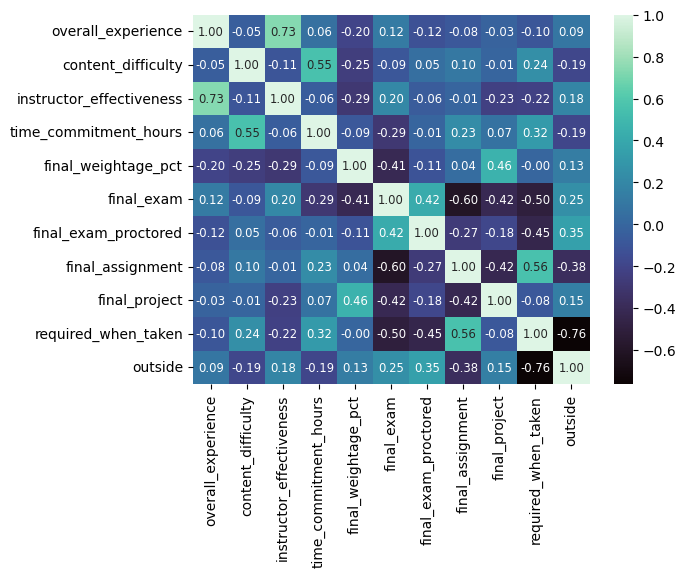

In [20]:
all_reviews = all_reviews.replace({True: 1, False: 0})
sns.heatmap(
    all_reviews.corr(numeric_only=True),
    annot=True,  
    fmt=".2f",
    cmap='mako',
    annot_kws={'fontsize': 'small'}
)

Firstly, since we will be modeling (a feature computed from) `'overall_experience'`,
note especially the high positive correlation with `'instructor_effectiveness'`.
There is a modest negative correlation between `'overall_experience'` and
`'final_weightage_pct'`.

There are numerous other correlations in the data between features that might be used
as predictors:
* The `'final_...'` data features I added are all strongly correlated, because
most courses only have one type of final (exam, assignment, or project), meaning they are
*nearly* mutually exclusive. (`'final_exam'` and `'final_exam_proctored'` are positively
correlated, because the latter is a subset of the former.)
* Strong correlation is also seen between `'required_when_taken'` and `'outside'` (i.e.,
outside electives), because outside electives are never required.
(A *quantity* of outside electives have been *de facto* required because there haven't
been enough in-MSCS electives to satisfy the degree requirements, but no *specific* outside
electives were required.)
* Also of note, `'final_exam'` and `'final_weightage_pct'` are negatively correlated somewhat
strongly -- i.e., when a class has a final exam, it tends to not coincide with a high
weighting for that final exam. Conversely, `'final_project'` and `'final_weightage_pct'` are
positively correlated.

### Histograms

The relative sparesness of overal ratings of `1` and `2` proves a substantial hindrance in modeling
the full gamut of reviews (`1` to `5`).

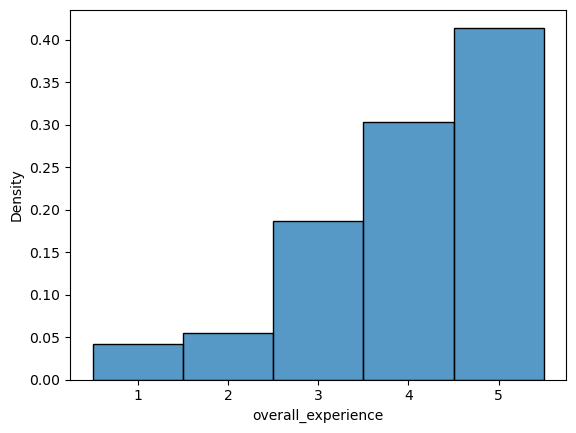

In [21]:
sns.histplot(data=all_reviews['overall_experience'], bins=5, discrete=True, stat='density')
plt.show()

When limiting the reviews to courses within the MSCS (excluding outside electives),
there are somewhat more `1`s, but still not enough.

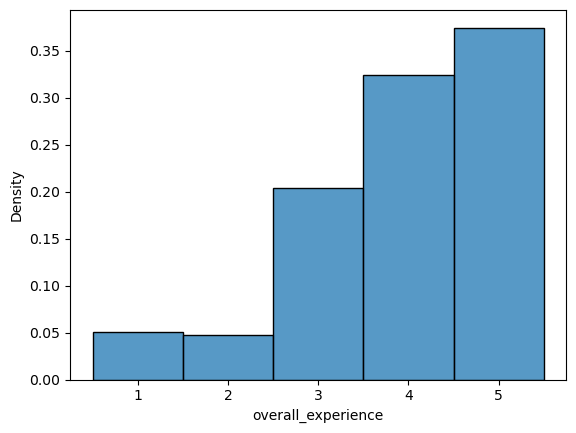

In [22]:
sns.histplot(data=all_reviews[all_reviews['outside'] == 0]['overall_experience'], bins=5, discrete=True, stat='density')
plt.show()

### Simplifying the problem to Binary Classification of 4-star vs. 5-star reviews

With the available data, I couldn't build a model that would sufficiently distinguish
reviews with high ratings (4 or 5) from reviews with lower ratings (1, 2, or 3).
But the data allow us to distinguish 4- and 5-star reviews from one another.
Thus, we've simplified our problem to parsing out what separates an exceptional review
from a "good" review.

In [23]:
highly_reviewed = all_reviews.copy()
highly_reviewed = highly_reviewed[highly_reviewed['overall_experience'] >= 4]
highly_reviewed['5stars'] = highly_reviewed['overall_experience'] == 5
# Move '5stars' to first column and drop 'overall_experience'.
columns = list(highly_reviewed.columns)
columns[0] = columns.pop(-1)
highly_reviewed = highly_reviewed[columns]

target = '5stars'
# Encode all binary categorizations as {0, 1}.
highly_reviewed = highly_reviewed.replace({True: 1, False: 0})
highly_reviewed = highly_reviewed.dropna()

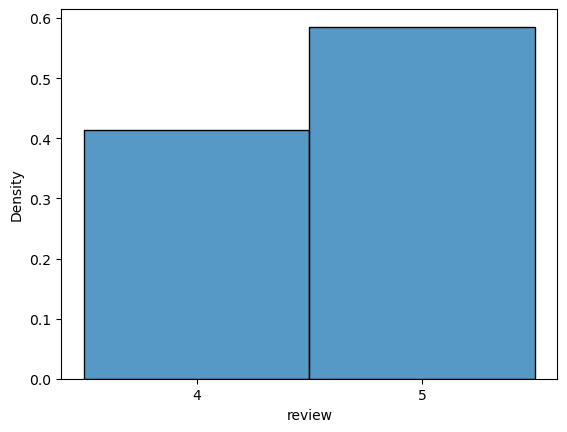

In [24]:
hp = sns.histplot(data=highly_reviewed.replace({0: 4, 1: 5})['5stars'], bins=2, discrete=True, stat='density')
hp.set_xlabel('review')
hp.set_xticks((4, 5))
plt.show()

### Correlation Heatmap of simplified problem

The correlations change with the new subset of data. Most notably, `'instructor_effectiveness'`
still correlates with `'5stars'` (computed from `'overall_experience'`), but now somewhat less so.

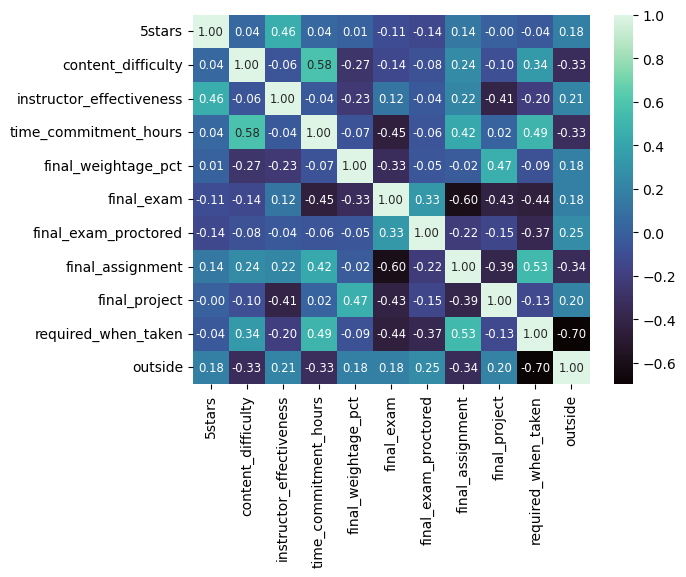

In [25]:
sns.heatmap(
    highly_reviewed.corr(numeric_only=True),
    annot=True,  
    fmt=".2f",
    cmap='mako',
    annot_kws={'fontsize': 'small'}
)
plt.show()

# Modeling

Given the relatively small dataset, we'll opt for k-fold cross-validation (k=10) instead
of splitting testing and training data.

We'll build three different types of models:
* __Random Forest Classifier__
* __Histogram-based Gradient Boosting Classifier__
* __Logistic Regression Classifier__

For the logistic regression, we'll use __forward stepwise selection__ to identify which features to use;
and we'll also build one with manually selected features.

In [26]:
exclude_features = []  # Any features we want to bar from consideration.
available_features = highly_reviewed.columns.symmetric_difference([target] + exclude_features)
X_all = highly_reviewed[available_features]
y_all = highly_reviewed[target]

# # Nope!
# split=0.2
# X_train, X_test = train_test_split(X_all, test_size=split)
# y_train, y_test = train_test_split(y_all, test_size=split)

In [27]:
def run_cv(clf, X, y, cv=10, print_it=True):
    """Helper function to run cross-validation and calculate scores."""
    results = cross_validate(clf, X, y, cv=cv, scoring=['precision', 'recall', 'f1'])
    precision = np.mean(results['test_precision'])
    recall = np.mean(results['test_recall'])
    f1 = np.mean(results['test_f1'])
    scores = {
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    if print_it:
        print(f"precision: {precision:.3f}")
        print(f"recall: {recall:.3f}")
        print(f"f1: {f1:.3f}")
    return scores

In [28]:
# Keep scores until conclusion section.
score_keeper = {}
# Keep names of models and short versions.
short_names = {}

### Random Forest Classification with 10-fold CV

In [29]:
model_name = 'Random Forest Classification'
short_name = 'RFC'
clf = RandomForestClassifier(n_estimators=100)

# Use all available features for RFC.

score_keeper[model_name] = run_cv(clf, X_all, y_all)
short_names[model_name] = short_name

precision: 0.728
recall: 0.723
f1: 0.710


### Histogram-Based Gradient Boosting Classifier with 10-fold CV

Note: [Histograph-Based Gradient Boosting](https://scikit-learn.org/stable/modules/ensemble.html#histogram-based-gradient-boosting)
allows us to pass a mask to tell the classifier which features are categorical.

In [30]:
model_name = 'Gradient Boosting Classification'
short_name = 'GBC'

# Use all available features for GBC, but mask those features that are categorical.
cat_feats = [
    # 'content_difficulty',
    # 'instructor_effectiveness',
    # 'time_commitment_hours',
    'required_when_taken',
    # 'final_weightage_pct',
    'final_exam',
    'final_exam_proctored',
    'final_assignment',
    'final_project',
    'outside'
]
cat_feats_mask = [ft in cat_feats for ft in available_features]
clf = HistGradientBoostingClassifier(categorical_features=cat_feats_mask, min_samples_leaf=70)

score_keeper[model_name] = run_cv(clf, X_all, y_all)
short_names[model_name] = short_name

precision: 0.813
recall: 0.703
f1: 0.734


### LogisticRegression with Stepwise Forward Selection

A simpler approach, and one that is much more interpretable. We allow sklearn's
sequential feature selector to determine how many features to select, and it chooses 5.

In [31]:
model_name = 'Logistic Regression (with stepwise forward selection)'
short_name = 'Logistic (stepwise)'

clf = LogisticRegression(solver='liblinear')
selector = SequentialFeatureSelector(clf, cv=10, n_features_to_select='auto')
# Allow the selector to choose any of the available features.
selector.fit(X_all, y_all)
lr_selected_features = selector.get_feature_names_out()
print(f"Selected features ({len(lr_selected_features)}): {', '.join(lr_selected_features)}")

Selected features (5): content_difficulty, final_assignment, final_exam, final_project, instructor_effectiveness


In [32]:
X_selected = X_all[lr_selected_features]
# Note that we're running this on X_selected, not X_all.
score_keeper[model_name] = run_cv(clf, X_selected, y_all)
short_names[model_name] = short_name

# Rank importance for later.
clf.fit(X_selected, y_all)
importances = permutation_importance(clf, X_selected, y_all)
features_and_importances = [(feat, imp_mean) for feat, imp_mean in zip(lr_selected_features, importances['importances_mean'])]
features_and_importances.sort(key=lambda tup: tup[1], reverse=True)
most_important_features = [ft for ft, _ in features_and_importances]

precision: 0.779
recall: 0.818
f1: 0.786


We'll also fit a logistic regression with manually selected features (choosing a subset of the
features selected by the sequential feature selector above).

In [33]:
model_name = 'Logistic Regression (with manual feature selection)'
short_name = 'Logistic (manual)'

clf = LogisticRegression(solver='liblinear')
# Train on these manually selected features.
lr_selected_features_manual = ['instructor_effectiveness', 'final_exam', 'content_difficulty']
X_selected_manual = X_all[lr_selected_features_manual]
score_keeper[model_name] = run_cv(clf, X_selected_manual, y_all)
short_names[model_name] = short_name

precision: 0.785
recall: 0.790
f1: 0.779


#### Helper Functions

*Ignore these helper functions. They're used for discussion in the next section.*

In [34]:
def print_scores(score_dict):
    """Ugly function to print out the table of scores."""
    print_order = ['precision', 'recall', 'f1']
    c1_just = max(len(k) for k in score_dict.keys()) + 2
    c2_just = max(len(s) for s in print_order)
    headers = f"{'Model Name'.rjust(c1_just, ' ')}"
    for score_name in print_order:
        headers = f"{headers} | {score_name.center(c2_just, ' ')}"
    rows = []
    for model_name, scores in score_dict.items():
        s = f"{model_name.rjust(c1_just, ' ')}"
        for score_name, value in scores.items():
            s += " | " + f"{value:.3}".rjust(c2_just, ' ')
        rows.append(s)
    
    line_divider = f"\n{'-' * len(headers)}\n"
    print(headers, end=line_divider)
    print(line_divider.join(rows))

def barplot_scores(score_dict, short_name_dict, palette=None):
    """Helper function to plot the overall scores."""
    results_list = [{'model': k for k in score_keeper.keys()}]
    rows = []
    for model, scores in score_dict.items():
        for score, val in scores.items():
            row = {'measure': score, 'score': val, 'model': short_name_dict[model]}
            rows.append(row)
            
    results = pd.DataFrame(rows)
    sns.barplot(results, x='measure', y='score', hue='model', palette=palette)
    plt.xlabel('')
    plt.legend(loc='lower right', framealpha=1.0)
    plt.show()


## Model Scores

                                             Model Name | precision |   recall  |     f1   
-------------------------------------------------------------------------------------------
                           Random Forest Classification |     0.728 |     0.723 |      0.71
-------------------------------------------------------------------------------------------
                       Gradient Boosting Classification |     0.813 |     0.703 |     0.734
-------------------------------------------------------------------------------------------
  Logistic Regression (with stepwise forward selection) |     0.779 |     0.818 |     0.786
-------------------------------------------------------------------------------------------
    Logistic Regression (with manual feature selection) |     0.785 |      0.79 |     0.779


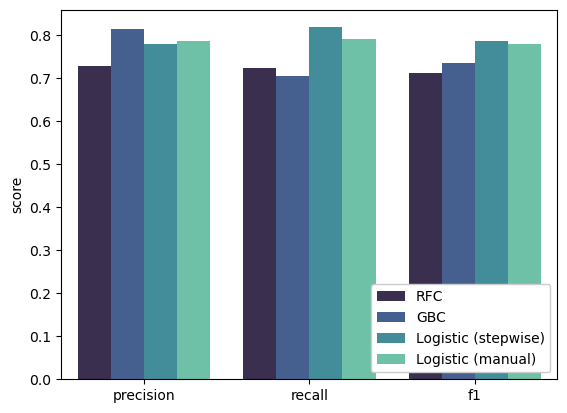

In [35]:
print_scores(score_keeper)
barplot_scores(score_keeper, short_names, palette='mako')

## Model Selection / Conclusions
As seen in the table and bar plot above, __gradient boosting__ resulted in a precision that was stronger than the other models,
but it came at a substantial cost to its recall score.
On the other hand, __logistic regression__ (especially as built by stepwise forward
feature selection) acheived a precision that was nearly as good, with a much stronger recall.
__Random forest classification__ underperformed the other models but had some predictive power.

#### Comparing the logistic regression models.

The logistic regression model that was built by stepwise forward selection performed best,
and it chose the following features (in order of their importance):

In [36]:
for i, (feat) in enumerate(most_important_features, start=1):
    print(f"  {i})", feat)

  1) instructor_effectiveness
  2) final_exam
  3) final_project
  4) content_difficulty
  5) final_assignment


Recall that the categorical features `'final_exam'` (and `'final_exam_proctored'`), `'final_project'`, and `'final_assignment'`
have strong correlations, because most courses have been designed with either a final exam (which may or may not be
proctored) or a final project or a final assignment -- but only rarely more than one. A second logistic regression
model was trained using manually selected features `'instructor_effectiveness'`, `'final_exam'`, and `'content_difficulty'`
nevertheless resulted in somewhat lower recall and f1 values and approximately equal recall (varies depending on the
cross-validation), as compared with the stepwise-trained model.

Both logistic regression models are interpretable, in that we can see the factors that influence
a student's overall perception of the class: How well the instructor teaches, what kind of final
project it has, and how difficult the content is.

Other factors such as the weighting of the final exam/project, whether a class is required, and
how many hours a class required do not hold as much importance in our models. Very possibly,
these features could impact the *__overall__* score given in a review (i.e., 1 through 5), but
our models were designed only to parse apart already high-scored reviews (scores of 4 and 5 only).

Given the interpretability, the comparably strong precision, and the much stronger recall
of __the stepwise-trained logistic regression model__, that is the clear winner of the
models tested here.

Unfortunately, my original goals with this project weren't borne out with the data available.
Possibly I could still figure out a model strategy that would get at the reviews with lower ratings,
but I suspect the data sparseness (especially at the lower end of the spectrum makes) makes it a
hard problem to solve currently.
It would be interesting to try something similar a few years down the line, once more students
have gone through CU Boulder's MSCS program.

## Acknowledgments

Thanks to my fellow students for encouragement and guidance. In particular, thanks to Razuki
for facilitating a great online student group for such an unusual program, and for maintaining
the spreadsheet that was the basis for this project (and which I've referenced at least 200
times since starting this MSCS program in January 2023).

If you haven't already, join us on Discord: https://discord.com/invite/a4aJeGeH8n